<a href="https://colab.research.google.com/github/peterbabulik/QuantumWalker/blob/main/13_TeV_proton_proton_collision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Source of data:
https://www.hepdata.net/record/82616

Please upload the 'HEPData-ins1627873-v1-Table_2.csv' file.


Saving HEPData-ins1627873-v1-Table_2.csv to HEPData-ins1627873-v1-Table_2 (3).csv

File 'HEPData-ins1627873-v1-Table_2 (3).csv' uploaded successfully.

Successfully parsed the multi-block file into separate dataframes.

Data successfully merged and uncertainties calculated.

Generating plot...


/tmp/ipython-input-3-3207048928.py:136: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


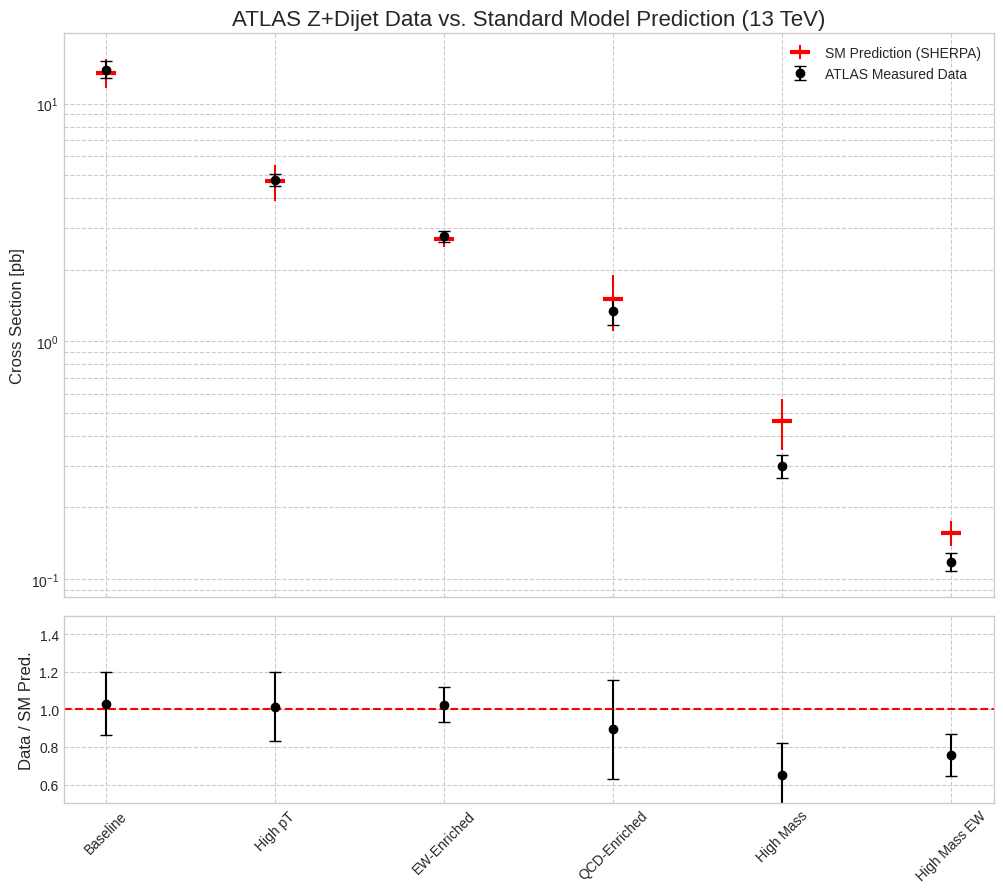


--- Quantitative Anomaly Check ---
Results for the highest-energy regions:
region_short  Inclusive $Zjj$ cross-sections [pb]_measured  Inclusive $Zjj$ cross-sections [pb]_theory    ratio  sigma_deviation
   High Mass                                         0.300                                       0.460 0.652174        -4.824182
High Mass EW                                         0.118                                       0.156 0.756410        -3.726207

YOUR HYPOTHESIS PREDICTS: The 'ratio' should be less than 1.0.
A 'sigma_deviation' that is negative and large (e.g., < -1.5) would be an interesting tension with the Standard Model.


In [3]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files
import io

# ==============================================================================
#  STEP 1: UPLOAD AND PARSE THE MULTI-BLOCK DATA FILE
# ==============================================================================

print("Please upload the 'HEPData-ins1627873-v1-Table_2.csv' file.")
uploaded = files.upload()

if not uploaded:
    raise ValueError("No file uploaded. Please run the cell again.")

filename = list(uploaded.keys())[0]
print(f"\nFile '{filename}' uploaded successfully.")

# Read the entire file content into memory
file_content = io.BytesIO(uploaded[filename]).read().decode('utf-8')

# Split the file content into blocks based on the '#: ,' delimiter
blocks = file_content.split('#: ,')

# Create a dictionary to hold the DataFrames for each block
dataframes = {}
parser_map = {
    'Measured': 'measured',
    'SHERPA(QCD-$Zjj$)+POWHEG(EW-$Zjj$)': 'theory_sherpa',
    'MG5_aMC(QCD-$Zjj$)+POWHEG(EW-$Zjj$)': 'theory_mg5',
    'ALPGEN (QCD-$Zjj$)+POWHEG(EW-$Zjj$)': 'theory_alpgen'
}

for block in blocks:
    if not block.strip():
        continue

    lines = block.strip().split('\n')
    header = lines[0]

    for key, name in parser_map.items():
        if key in header:
            # Use io.StringIO to treat the string block as a file for pandas
            csv_io = io.StringIO('\n'.join(lines[1:]))
            df = pd.read_csv(csv_io)
            # Standardize the first column name for merging
            df.rename(columns={df.columns[0]: 'Fiducial region'}, inplace=True)
            dataframes[name] = df
            break

print("\nSuccessfully parsed the multi-block file into separate dataframes.")

# ==============================================================================
#  STEP 2: DATA PREPARATION AND MERGING
# ==============================================================================

# Extract the measured data and the primary theory prediction (SHERPA)
df_measured = dataframes['measured']
df_theory = dataframes['theory_sherpa']

# Merge the two dataframes on the 'Fiducial region' column
df_merged = pd.merge(df_measured, df_theory, on='Fiducial region', suffixes=('_measured', '_theory'))

# --- Uncertainty Calculation ---
# Combine the separate uncertainties (stat, sys, lumi) in quadrature for the measured data
# Total positive uncertainty = sqrt(stat+^2 + sys+^2 + lumi+^2)
df_merged['total_unc_pos'] = np.sqrt(
    df_merged['stat +']**2 + df_merged['sys +']**2 + df_merged['lumi +']**2
)
# Total negative uncertainty = sqrt(stat-^2 + sys-^2 + lumi-^2)
# The negative errors are given as negative numbers, so we take the absolute value
df_merged['total_unc_neg'] = np.sqrt(
    df_merged['stat -'].abs()**2 + df_merged['sys -'].abs()**2 + df_merged['lumi -'].abs()**2
)

# The theory uncertainty is already combined, but we'll rename for clarity
df_merged.rename(columns={'stat+sys +': 'theory_unc_pos', 'stat+sys -': 'theory_unc_neg'}, inplace=True)


print("\nData successfully merged and uncertainties calculated.")

# ==============================================================================
#  STEP 3: VISUALIZATION - DATA vs. THEORY
# ==============================================================================

print("\nGenerating plot...")

# Abbreviate the long region names for better plotting
region_map = {
    'Baseline': 'Baseline',
    'High-p_{T}': 'High pT',
    'EW-enriched': 'EW-Enriched',
    'QCD-enriched': 'QCD-Enriched',
    'High-mass': 'High Mass',
    'EW-enriched ($m_{jj}>$ 1 TeV)': 'High Mass EW'
}
df_merged['region_short'] = df_merged['Fiducial region'].map(region_map)

plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

# --- Top Plot: The Main Measurement ---
ax1.set_title('ATLAS Z+Dijet Data vs. Standard Model Prediction (13 TeV)', fontsize=16)

# Plot the theory prediction with its uncertainty band
ax1.errorbar(df_merged['region_short'], df_merged['Inclusive $Zjj$ cross-sections [pb]_theory'],
             yerr=[df_merged['theory_unc_neg'].abs(), df_merged['theory_unc_pos']],
             fmt='r_', mew=3, ms=15, label='SM Prediction (SHERPA)')

# Plot the measured data with its total uncertainty
ax1.errorbar(df_merged['region_short'], df_merged['Inclusive $Zjj$ cross-sections [pb]_measured'],
             yerr=[df_merged['total_unc_neg'], df_merged['total_unc_pos']],
             fmt='ko', capsize=4, label='ATLAS Measured Data')

ax1.set_ylabel('Cross Section [pb]', fontsize=12)
ax1.set_yscale('log')
ax1.legend()
ax1.grid(True, which='both', linestyle='--')

# --- Bottom Plot: The Ratio (Where Anomalies Appear) ---
ratio = df_merged['Inclusive $Zjj$ cross-sections [pb]_measured'] / df_merged['Inclusive $Zjj$ cross-sections [pb]_theory']
# Propagate the uncertainties for the ratio
ratio_unc = ratio * np.sqrt(
    ( (df_merged['total_unc_pos'] + df_merged['total_unc_neg'])/2 / df_merged['Inclusive $Zjj$ cross-sections [pb]_measured'] )**2 +
    ( (df_merged['theory_unc_pos'] + df_merged['theory_unc_neg'].abs())/2 / df_merged['Inclusive $Zjj$ cross-sections [pb]_theory'] )**2
)

ax2.errorbar(df_merged['region_short'], ratio, yerr=ratio_unc, fmt='ko', capsize=4)
ax2.axhline(y=1.0, color='r', linestyle='--')
ax2.set_ylabel('Data / SM Pred.', fontsize=12)
ax2.set_ylim(0.5, 1.5)
ax2.grid(True, which='both', linestyle='--')
plt.xticks(rotation=45) # Rotate labels for better readability
plt.tight_layout()
plt.show()

# ==============================================================================
#  STEP 4: QUANTITATIVE ANALYSIS OF HIGH-ENERGY BINS
# ==============================================================================

print("\n--- Quantitative Anomaly Check ---")
# Focus on the two highest-energy categories
high_energy_data = df_merged[df_merged['region_short'].isin(['High Mass', 'High Mass EW'])].copy()

# Calculate the ratio for this subset
high_energy_data['ratio'] = high_energy_data['Inclusive $Zjj$ cross-sections [pb]_measured'] / high_energy_data['Inclusive $Zjj$ cross-sections [pb]_theory']

# Calculate the total uncertainty of the measurement
high_energy_data['total_unc'] = (high_energy_data['total_unc_pos'] + high_energy_data['total_unc_neg']) / 2.0

# Calculate the deviation in terms of standard deviations (sigma)
high_energy_data['sigma_deviation'] = (high_energy_data['Inclusive $Zjj$ cross-sections [pb]_measured'] - high_energy_data['Inclusive $Zjj$ cross-sections [pb]_theory']) / high_energy_data['total_unc']


print("Results for the highest-energy regions:")
print(high_energy_data[['region_short', 'Inclusive $Zjj$ cross-sections [pb]_measured', 'Inclusive $Zjj$ cross-sections [pb]_theory', 'ratio', 'sigma_deviation']].to_string(index=False))

print("\nYOUR HYPOTHESIS PREDICTS: The 'ratio' should be less than 1.0.")
print("A 'sigma_deviation' that is negative and large (e.g., < -1.5) would be an interesting tension with the Standard Model.")